# The Great American Coffee Taste Test : Predicting Daily Coffee Consumption
## STAT 301 — Group Final Report

**Group 9: Best Fits**
**Group Members:** Tiffany Nguyen, Makafui Amouzouvi, Adam Cook, Nolan Bishop
**Dataset:** The Great American Coffee Taste Test (TidyTuesday, 2024-05-14)

April 16, 2026

In [31]:
# Load required libraries
library(tidyverse)
library(knitr)
library(broom)
library(glmnet)

---
# 1. Introduction

### Background

In October 2023, world-champion barista James Hoffmann and coffee company Cometeer hosted "The Great American Coffee Taste Test" as a YouTube livestream. Approximately 4,000 participants across the United States received four flash-frozen coffee samples and tasted them blind while following along with the stream. After tasting, participants completed a detailed online survey covering their demographics, coffee habits, and ratings for each of the four coffees. The data was subsequently made public by data blogger Robert McKeon Aloe and later published through the TidyTuesday project (week of May 14, 2024).

**Important caveat:** Because participation was voluntary and the audience consisted primarily of James Hoffmann's fanbase, the sample is not representative of the general American population.

**Citation:**  
McKeon Aloe, R. (2023). *Great American Coffee Taste Test Breakdown*. Medium. https://rmckeon.medium.com/great-american-coffee-taste-test-breakdown-7f3fdcc3c41d  
TidyTuesday (2024-05-14). https://github.com/rfordatascience/tidytuesday/blob/main/data/2024/2024-05-14/readme.md

**Research Question**

> ***Can we use career/occupational characteristics (wfh, employment_status, education_level) and coffee-drinking habits (total_spend, spent_equipment, self-reported coffee expertise, preferred roast level, preferred strength etc) to predict the number of cups of coffee a person drinks per day?***

The question remains focused on **prediction**: whether a set of career and habit variables can meaningfully predict daily coffee consumption for new individuals. Because the data come from a voluntary survey (observational study), we cannot make causal claims. The question is framed strictly in terms of *prediction*. The primary goal is to build a model that can accurately estimate the daily coffee consumption count for new individuals. 

---
## 2. Methods and Results

### 2a. Data

In [32]:
# Load data directly from GitHub (reproducible — no local files)
coffee_survey <- readr::read_csv(
  'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv',
  show_col_types = FALSE
)

cat("Number of observations:", nrow(coffee_survey), "\n")
cat("Number of variables:", ncol(coffee_survey), "\n")
unique(coffee_survey$employment_status)

Number of observations: 4042 
Number of variables: 57 


[1] NA                   "Employed full-time" "Unemployed"        
[4] "Student"            "Employed part-time" "Retired"           
[7] "Homemaker"

In [33]:
# Create a readable table of variable names and types
var_table <- tibble(
  Variable = names(coffee_survey),
  Type = sapply(coffee_survey, class)
)

kable(var_table, caption = "Table 1: Variable names and data types in the coffee_survey dataset")




Table: Table 1: Variable names and data types in the coffee_survey dataset

|Variable                     |Type      |
|:----------------------------|:---------|
|submission_id                |character |
|age                          |character |
|cups                         |character |
|where_drink                  |character |
|brew                         |character |
|brew_other                   |character |
|purchase                     |character |
|purchase_other               |character |
|favorite                     |character |
|favorite_specify             |character |
|additions                    |character |
|additions_other              |character |
|dairy                        |character |
|sweetener                    |character |
|style                        |character |
|strength                     |character |
|roast_level                  |character |
|caffeine                     |character |
|expertise                    |numeric   |
|coffee_a_bitternes

The dataset contains **4,042 observations** and **57 variables**, covering participant demographics, coffee consumption habits, and blind taste-test ratings for four coffees.

**Response Variable:** Our response variable is cups of coffee consumed per day (cups). 

**Data Collection**

The data were collected via a voluntary online survey linked to a YouTube livestream event on October 21, 2023. Participants self-selected into the study by purchasing a Cometeer coffee kit in advance. Because the sample is self-selected and drawn from the audience of a specific content creator, we assume the data represent a **convenience sample** and may not generalize to all American coffee drinkers.

**Variable types:** Most demographic and preference variables are stored as character strings (e.g., `age`, `roast_level`, `strength`). A small number are numeric (e.g., `expertise`, taste-test ratings). The response variable `cups` records self-reported daily consumption as an ordered string category.

**Citation:**  
The data is pulled from this repo https://github.com/rfordatascience/tidytuesday/blob/main/data/2024/2024-05-14/readme.md

**Variable exclusions:** Since our question is focused on career/occupational characteristics and coffee-drinking habits, we can justifiably drop variables/columns that are not part of these characteristics. That means we can drop:

- **Demographics variables**: `age`, `gender`, `gender_specify`, `ethnicity_race`, `ethnicity_race_specify`, `number_children`, `political_affiliation`
- **Admin**: `submission_id`
- **Tasting experiment variables**: `coffee_a_bitterness`, `coffee_a_acidity`, `coffee_a_personal_preference`, `coffee_a_notes`, `coffee_b_bitterness`, `coffee_b_acidity`, `coffee_b_personal_preference`, `coffee_b_notes`, `coffee_c_bitterness`, `coffee_c_acidity`, `coffee_c_personal_preference`, `coffee_c_notes`, `coffee_d_bitterness`, `coffee_d_acidity`, `coffee_d_personal_preference`, `coffee_d_notes`, `prefer_abc`, `prefer_ad`, `prefer_overall`, `favorite`,`favorite_specify`, `style`. ***These tasting-related variables capture responses to a specific blind tasting event and reflect perceptions of individual coffee samples rather than habitual drinking behaviour. Since our research question concerns daily consumption patterns, these variables are outside the scope of our analysis.***

**Pre-variables selections:** Our questions focuses on career/occupational characteristics and coffee-drinking habits, so anticipate these variables to be included: 

**Key Anticipated Covariates**

- **`wfh`** (categorical): People who work from home may have easier access to coffee, especially if they have a coffee machine
- **`employment_status`**: consumption habits likely vary. Students, for example, may drink more coffee.
- **`total_spend`**: People who spend more money on coffee per month may drink more etc..
- **`expertise`** (numeric, 1–10 self-rated): people who consider themselves coffee experts may drink more.
- **`age`** (categorical): consumption habits likely vary across age groups.
- **`roast_level`** (categorical): preference for stronger roasts may correlate with higher consumption.
- **`strength`** (categorical): preferred coffee strength is likely directly related to quantity consumed.
- **`caffeine`** (categorical): those who care about caffeine may consume more cups.
`
We may include more variables and remove some after the EDA. 

A LASSO regression model was used to predict daily coffee consumption (cups) using demographic and coffee habit variables. The model selected a subset of predictors by shrinking less important coefficients to zero.

The following variables were excluded from the model (coefficients shrunk to zero):

**roast_level (Medium), know_source, most_paid (15–20), spent_equipment (300–500).**

Among the retained predictors, higher coffee consumption was strongly associated with greater total spending on coffee, particularly for individuals spending more than $80 per month. Preference for full caffeine and darker roast levels (e.g., French and Italian) were also associated with increased consumption.

In contrast, lower spending levels, preference for weaker coffee, and certain employment categories (e.g., unemployed) were associated with reduced coffee consumption.

Overall, the LASSO model suggests that **coffee-related behaviors and spending patterns are stronger predictors of daily consumption than demographic characteristics.**

In [47]:
# variable selection via LASSO 

# data preprocessing  
LASSO_df <- coffee_survey %>%
    # turn cups into numeric 
    mutate(
    cups = case_when(
        cups == "Less than 1" ~ 0.5,
        cups == "1" ~ 1,
        cups == "2" ~ 2,
        cups == "3" ~ 3,
        cups == "4" ~ 4,
        cups == "More than 4" ~ 5)
    ) %>%
    # selected interested columns
    select(cups, 
           strength, 
           roast_level,
           caffeine, 
           expertise, 
           wfh, 
           total_spend, 
           know_source, 
           most_paid, 
           most_willing, 
           value_cafe, 
           spent_equipment, 
           education_level, 
           employment_status
    ) %>% 
    # turn character into factor
    mutate(across(where(is.character), as.factor)
    ) %>%
    # drop NAs 
    drop_na()

# convert categorical varible
X <- model.matrix(cups ~ ., data = LASSO_df)[, -1]
y <- LASSO_df$cups

# apply LASSO 
lasso_model <- glmnet(
  x = X,
  y = y,
  alpha = 1   # LASSO
)

cv_model <- cv.glmnet(X, y, alpha = 1)

best_lambda <- cv_model$lambda.min

# final model 
final_model <- glmnet(X, y, alpha = 1, lambda = best_lambda)

# extract selected variables 
coef(final_model)

53 x 1 sparse Matrix of class "dgCMatrix"
                                                             s0
(Intercept)                                        0.5315902363
strengthSomewhat light                            -0.1042287079
strengthSomewhat strong                            0.0696956797
strengthVery strong                                0.1614188095
strengthWeak                                      -0.1313417284
roast_levelDark                                    0.0976055917
roast_levelFrench                                  0.4740142128
roast_levelItalian                                 0.2079633038
roast_levelLight                                  -0.0281432536
roast_levelMedium                                  .           
roast_levelNordic                                  0.0792774108
caffeineFull caffeine                              0.3730173462
caffeineHalf caff                                  0.0994182569
expertise                                          0.067758765

### 2b. Exploratory Data Analysis (EDA)

### 2.b.1. Clean Data
We first need to clean the data and drop the variables not related to the question we are exploring as mentioned previously

In [34]:
# clean data 

# Drop the variables not related to the research questions
coffee_clean <- coffee_survey |>
  select(-c(
    # Demographics
    age, gender, gender_specify, ethnicity_race, ethnicity_race_specify, 
    number_children, political_affiliation,
    
    # Admin
    submission_id,
    
    # Tasting experiment
    coffee_a_bitterness, coffee_a_acidity, coffee_a_personal_preference, coffee_a_notes,
    coffee_b_bitterness, coffee_b_acidity, coffee_b_personal_preference, coffee_b_notes,
    coffee_c_bitterness, coffee_c_acidity, coffee_c_personal_preference, coffee_c_notes,
    coffee_d_bitterness, coffee_d_acidity, coffee_d_personal_preference, coffee_d_notes,
    prefer_abc, prefer_ad, prefer_overall, favorite, favorite_specify, style
  ))

# standardize casing 
coffee_clean <- coffee_clean %>%
  mutate(across(where(is.character), ~ tolower(.x)))

tail(coffee_clean, 3)

cups,where_drink,brew,brew_other,purchase,purchase_other,additions,additions_other,dairy,sweetener,⋯,why_drink_other,taste,know_source,most_paid,most_willing,value_cafe,spent_equipment,value_equipment,education_level,employment_status
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,"at a cafe, at home, on the go, at the office","espresso, pod/capsule machine (e.g. keurig/nespresso), instant coffee, other",aeropress,"national chain (e.g. starbucks, dunkin), drive-thru, local cafe, specialty coffee shop",NA,"no - just black, milk, dairy alternative, or coffee creamer, flavor syrup",NA,"oat milk, coffee creamer, flavored coffee creamer",NA,⋯,NA,yes,yes,$8-$10,more than $20,yes,$300-$500,yes,some college or associate's degree,employed full-time
2,at home,pour over,NA,NA,NA,"milk, dairy alternative, or coffee creamer",NA,whole milk,NA,⋯,NA,yes,yes,$4-$6,$8-$10,yes,$100-$300,yes,bachelor's degree,unemployed
1,at home,"pour over, french press, espresso, other",aeropress,NA,NA,"milk, dairy alternative, or coffee creamer, sugar or sweetener",NA,whole milk,granulated sugar,⋯,NA,yes,yes,$15-$20,$15-$20,yes,$500-$1000,yes,doctorate or professional degree,employed full-time


### 2.b.2 : Handling missing data 
Now, let's investigate missing data. Since variables with a lot of missing data can impact the outcome of the research, we need to make sure we have enough data points for each variables being considered. 

In [35]:
# Count missing values and proportion for each variable
missing_summary <- coffee_clean |>
  summarise(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(everything(), names_to = "Variable", values_to = "Missing_Count") |>
  mutate(
    Total = nrow(coffee_clean),
    Proportion_Missing = round((Missing_Count / Total)*100, 4)
  ) |>
  arrange(desc(Proportion_Missing))
missing_summary

Variable,Missing_Count,Total,Proportion_Missing
<chr>,<int>,<int>,<dbl>
purchase_other,4011,4042,99.2331
additions_other,3994,4042,98.8125
why_drink_other,3875,4042,95.8684
sweetener,3530,4042,87.3330
brew_other,3364,4042,83.2261
purchase,3332,4042,82.4344
dairy,2356,4042,58.2880
employment_status,623,4042,15.4132
education_level,604,4042,14.9431


In [36]:
# Variables with > 20% missing
high_missing <- missing_summary |> filter(Proportion_Missing > 20)
cat("Variables with > 20% missing data:", nrow(high_missing), "\n")
print(high_missing |> select(Variable, Proportion_Missing))

#Drop 
coffee_trimmed <- coffee_clean |>
  select(-c(
    # Free-text "other" columns
    purchase_other,
    additions_other,
    why_drink_other,
    brew_other,
    
    # Too sparse to be useful (>58% missing)
    sweetener,
    purchase,
    dairy
  ))
cat("\n")
cat("Remaining columns:")
colnames(coffee_trimmed)

Variables with > 20% missing data: 7 
# A tibble: 7 × 2
  Variable        Proportion_Missing
  <chr>                        <dbl>
1 purchase_other                99.2
2 additions_other               98.8
3 why_drink_other               95.9
4 sweetener                     87.3
5 brew_other                    83.2
6 purchase                      82.4
7 dairy                         58.3

Remaining columns:

[1] "cups"              "where_drink"       "brew"             
 [4] "additions"         "strength"          "roast_level"      
 [7] "caffeine"          "expertise"         "wfh"              
[10] "total_spend"       "why_drink"         "taste"            
[13] "know_source"       "most_paid"         "most_willing"     
[16] "value_cafe"        "spent_equipment"   "value_equipment"  
[19] "education_level"   "employment_status"

**Several variables have more than 20% missing values. These variables with many missing values likely reflect that only participants who selected certain options (e.g., those who add dairy) were prompted to answer follow-up questions. Consequently, it makes sense to drop them. Our anticipated key variables for our research question `wfh`, `employment_status`, `total_spend`, `expertise`, `age`, `roast_level`, `strength`, `caffeine` have relatively low rates of missing values.**

### 2.b.3. Class Imbalance in Categorical Variables 

#### Part A: Everything except "why_drink", "additions", "brew", "where_drink")

In [37]:
vars_to_check <- colnames(coffee_trimmed)[!colnames(coffee_trimmed) %in% 
                   c("why_drink", "additions", "brew", "where_drink")]

for (var in vars_to_check) {
  cat("---", var, "---\n")
  coffee_trimmed |> 
    count(.data[[var]]) |> 
    mutate(prop = round(n / sum(n), 3)) |> 
    print()
  cat("\n")
}

--- cups ---
# A tibble: 7 × 3
  cups            n  prop
  <chr>       <int> <dbl>
1 1            1277 0.316
2 2            1663 0.411
3 3             473 0.117
4 4             121 0.03 
5 less than 1   348 0.086
6 more than 4    67 0.017
7 NA             93 0.023

--- strength ---
# A tibble: 6 × 3
  strength            n  prop
  <chr>           <int> <dbl>
1 medium           1432 0.354
2 somewhat light    217 0.054
3 somewhat strong  1791 0.443
4 very strong       433 0.107
5 weak               43 0.011
6 NA                126 0.031

--- roast_level ---
# A tibble: 8 × 3
  roast_level     n  prop
  <chr>       <int> <dbl>
1 blonde         74 0.018
2 dark          409 0.101
3 french         21 0.005
4 italian        23 0.006
5 light        1778 0.44 
6 medium       1557 0.385
7 nordic         78 0.019
8 NA            102 0.025

--- caffeine ---
# A tibble: 4 × 3
  caffeine          n  prop
  <chr>         <int> <dbl>
1 decaf           136 0.034
2 full caffeine  3576 0.885
3 half caff 


**`cups`** (outcome variable): Reasonably distributed. Most respondents drink 1–2 cups/day (73%), with very few drinking more than 4 (1.7%). Slight right skew. Low missingness (2.3%).

**`strength`**: Well distributed across meaningful categories. It is dominated by "somewhat strong" (44%) and "medium" (35%). "Weak" is rare (1.1%). We may consider merging with "somewhat light" before modelling. Low missingness (3.1%).

**`roast_level`**: Dominated by "light" (44%) and "medium" (39%). Several rare categories: `french` (0.5%), `italian` (0.6%), `blonde` (1.8%), `nordic` (1.9%). We should explore merging into an "other" category before modelling to avoid sparse levels. Low missingness (2.5%).

**`caffeine`**: Heavily skewed toward "full caffeine" (88.5%). `decaf` and `half caff` are minority classes. Low missingness (3.1%).

**`expertise`**: Numeric 1–10 scale. Right-skewed toward higher self-reported expertise (median around 6–7). Low missingness (2.6%).

**`wfh`**: Reasonably balanced across three meaningful categories. "Primarily work from home" is the most common (39.4%). Low missingness (12.8%).

**`total_spend`**: Concentrated in lower spend brackets: "$20–$40" (32%) and "$40–$60" (26%). Right-skewed as expected. Missingness at 13.1%.

**`taste`**: Heavily imbalanced - 85.6% said yes. Near-zero variance may have limited predictive value. We may consider dropping this before modelling. Missingness at 11.9%.

**`know_source`**: Moderately imbalanced, 67.3% yes. Still has enough variation to be useful. Missingness at 11.9%.

**`most_paid`**: Concentrated in "$6–$8" (27.1%) and "$8–$10" (24.7%). A few very rare low-spend categories (`less than $2` at 0.3%, `$2–$4` at 1.1%). We can consider merging before modelling. Missingness at 12.7%.

**`most_willing`**: Similar distribution to `most_paid`, concentrated in "$8–$10" (21.8%) and "$10–$15" (16.1%). Same rare low-spend categories may be worth merging. Missingness at 13.2%.

**`value_cafe`**: Reasonably balanced binary (51% yes, 36% no). Missingness (13.4%).

**`spent_equipment`**: Fairly well spread across categories. Notably bimodal — peaks at "$100–$300" (18.6%) and "more than $1,000" (19.3%), suggesting two distinct types of coffee drinkers. Missingness at 13.3%.

**`value_equipment`**: Heavily imbalanced — 82.1% yes. Similar to `taste`, near-zero variance may limit predictive usefulness. We may consider dropping before modelling. Missingness at 13.6%.

**`education_level`**: Dominated by bachelor's degree (43.5%). Relatively well distributed otherwise. "Less than high school" is very rare (0.5%). We may consider merging with "high school graduate". Missingness at 14.9%.

**`employment_status`**: Dominated by "employed full-time" (67%). `homemaker` (1.9%) and `retired` (2.1%) are rare. Missingness at 15.4%.


#### Summary
Most variables are fairly distributed. We will, however, drop `taste` (85.6% yes, near-zero variance), `value_equipment` (82.1% yes) because of the high class imbalance. As a result they are unlikely to contribute to our predictive model. 


In [38]:
# Drop taste and value equipment
coffee_balanced <- coffee_trimmed |>
  select(-c(
    taste,
    value_equipment
  ))

#### 2.b.3. Part B: Class imbalance for "why_drink", "additions", "brew", "where_drink."

In [39]:
# class imbalance why_drink
cat("--- why_drink ---\n")
cat("Number of unique categories:", n_distinct(coffee_balanced$why_drink), "\n\n")
head(coffee_balanced |> count(why_drink) |> mutate(prop = round(n / sum(n), 3)))

--- why_drink ---
Number of unique categories: 85 



why_drink,n,prop
<chr>,<int>,<dbl>
i need the caffeine,62,0.015
"i need the caffeine, i need the ritual",22,0.005
"i need the caffeine, i need the ritual, it makes me go to the bathroom",4,0.001
"i need the caffeine, i need the ritual, it makes me go to the bathroom, it tastes good",7,0.002
"i need the caffeine, i need the ritual, it tastes good",31,0.008
"i need the caffeine, i need the ritual, it tastes good, it makes me go to the bathroom",4,0.001


In [40]:
# class imbalance additions
cat("--- additions ---\n")
cat("Number of unique categories:", n_distinct(coffee_balanced$additions), "\n\n")
head(coffee_balanced |> count(additions) |> mutate(prop = round(n / sum(n), 3)))

--- additions ---
Number of unique categories: 54 



additions,n,prop
<chr>,<int>,<dbl>
flavor syrup,6,0.001
"flavor syrup, milk, dairy alternative, or coffee creamer",21,0.005
"flavor syrup, milk, dairy alternative, or coffee creamer, sugar or sweetener",1,0.000
"flavor syrup, no - just black, milk, dairy alternative, or coffee creamer",1,0.000
"flavor syrup, sugar or sweetener",1,0.000
"flavor syrup, sugar or sweetener, milk, dairy alternative, or coffee creamer",5,0.001


In [41]:
# class imbalance brew
cat("--- brew ---\n")
cat("Number of unique categories:", n_distinct(coffee_balanced$brew), "\n\n")
head(coffee_balanced |> count(brew) |> mutate(prop = round(n / sum(n), 3)))

--- brew ---
Number of unique categories: 450 



brew,n,prop
<chr>,<int>,<dbl>
bean-to-cup machine,20,0.005
"bean-to-cup machine, coffee extract (e.g. cometeer)",1,0.000
"bean-to-cup machine, coffee extract (e.g. cometeer), espresso, other, coffee brewing machine (e.g. mr. coffee)",1,0.000
"bean-to-cup machine, cold brew",3,0.001
"bean-to-cup machine, espresso",2,0.000
"bean-to-cup machine, espresso, coffee brewing machine (e.g. mr. coffee)",1,0.000


In [42]:
# class imbalance where_drink
cat("--- where_drink ---\n")
cat("Number of unique categories:", n_distinct(coffee_balanced$where_drink), "\n\n")
head(coffee_balanced |> count(where_drink) |> mutate(prop = round(n / sum(n), 3)))

--- where_drink ---
Number of unique categories: 66 



where_drink,n,prop
<chr>,<int>,<dbl>
at a cafe,71,0.018
"at a cafe, at home",85,0.021
"at a cafe, at home, at the office",16,0.004
"at a cafe, at home, at the office, on the go",6,0.001
"at a cafe, at home, on the go",15,0.004
"at a cafe, at home, on the go, at the office",6,0.001


**`why_drink`** (85 unique categories), **`additions`** (54 unique categories), **`brew`** (450 unique categories), and **`where_drink`** (66 unique categories) are multi-select survey questions. Because respondents could select multiple options, their responses were stored as comma-separated strings (e.g. `"i need the caffeine, i need the ritual, it tastes good"`), resulting in a large number of unique category combinations with very low frequencies. These variables cannot be used directly as categorical predictors in a model. To use them properly, each individual option would need to be extracted and encoded as a separate binary indicator variable. This is a process known as one-hot encoding of multi-select responses. As this is outside the scope of this course, we will drop these four variables.

In [43]:
# Drop why_drink, additions, brew, and where_drin
coffee_balanced_final <- coffee_balanced |>
  select(-c(
    why_drink,
    additions,
    brew,
    where_drink
  ))
tail(coffee_balanced_final)

cups,strength,roast_level,caffeine,expertise,wfh,total_spend,know_source,most_paid,most_willing,value_cafe,spent_equipment,education_level,employment_status
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
more than 4,somewhat strong,light,full caffeine,7,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,medium,medium,full caffeine,2,NA,$20-$40,no,$6-$8,$4-$6,no,less than $20,master's degree,retired
2,medium,light,full caffeine,2,NA,$20-$40,no,$4-$6,$2-$4,no,less than $20,bachelor's degree,retired
1,somewhat strong,light,full caffeine,5,i primarily work in person,$40-$60,yes,$8-$10,more than $20,yes,$300-$500,some college or associate's degree,employed full-time
2,somewhat strong,medium,full caffeine,6,i primarily work in person,$20-$40,yes,$4-$6,$8-$10,yes,$100-$300,bachelor's degree,unemployed
1,medium,medium,full caffeine,6,i primarily work in person,$20-$40,yes,$15-$20,$15-$20,yes,$500-$1000,doctorate or professional degree,employed full-time


### 2.b.4. Transformations

In [44]:
coffee_balanced_final <- coffee_balanced_final |>
  mutate(
    cups_numeric = case_when(
      cups == "less than 1" ~ 0,
      cups == "1"           ~ 1,
      cups == "2"           ~ 2,
      cups == "3"           ~ 3,
      cups == "4"           ~ 4,
      cups == "more than 4" ~ 5
    ),
    strength = factor(strength,
      levels = c("weak", "somewhat light", "medium", "somewhat strong", "very strong")
    ),
    roast_level = factor(roast_level,
      levels = c("light", "medium", "dark", "blonde", "nordic", "french", "italian")
    ),
    total_spend = factor(total_spend,
      levels = c("<$20", "$20-$40", "$40-$60", "$60-$80", "$80-$100", ">$100")
    ),
    spent_equipment = factor(spent_equipment,
      levels = c("less than $20", "$20-$50", "$50-$100",
                 "$100-$300", "$300-$500", "$500-$1000", "more than $1,000")
    ),
    most_paid = factor(most_paid,
      levels = c("less than $2", "$2-$4", "$4-$6", "$6-$8",
                 "$8-$10", "$10-$15", "$15-$20", "more than $20")
    ),
    most_willing = factor(most_willing,
      levels = c("less than $2", "$2-$4", "$4-$6", "$6-$8",
                 "$8-$10", "$10-$15", "$15-$20", "more than $20")
    )
  )

**Variable Transformations and Recoding**

**`cups` → `cups_numeric`:** The response variable was stored as an ordered string 
category. We converted it to a numeric count (0–5), treating "more than 4" as 5 since 
the survey does not capture the exact value for high consumers. This is required for 
Poisson regression, which expects a non-negative integer response.

**`strength` — ordered factor:** Recoded as an ordered factor from `"weak"` to 
`"very strong"` to reflect the natural intensity scale. This ensures correct axis 
ordering in plots.

**`total_spend`, `spent_equipment`, `most_paid`, `most_willing` - ordered factors:** 
These variables represent spending ranges with a natural ascending dollar order. 
Recoding them as ordered factors ensures correct axis ordering in visualizations. 

No log transformation of the response was applied since Poisson regression models 
the log of the mean internally. The numeric variable `expertise` was left as-is 
given its roughly symmetric distribution across the 1–10 scale.

### 2.b. 5. Visualizations

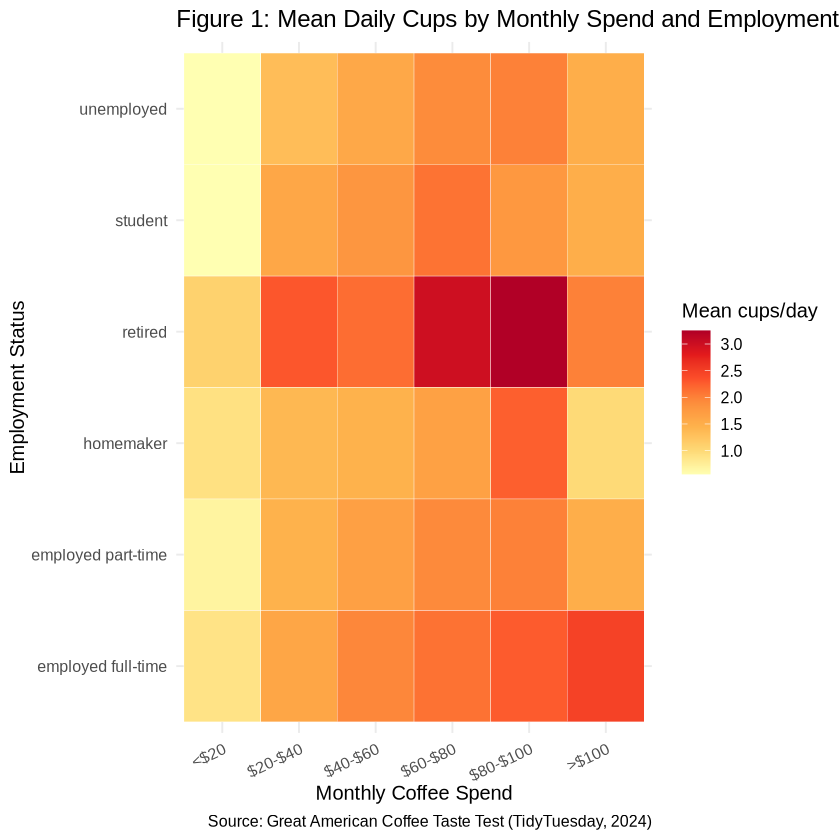

In [45]:
fig1 <- coffee_balanced_final |>
  filter(!is.na(cups_numeric), !is.na(total_spend), !is.na(employment_status)) |>
  group_by(employment_status, total_spend) |>
  summarise(mean_cups = mean(cups_numeric), .groups = "drop") |>
  ggplot(aes(x = total_spend, y = employment_status, fill = mean_cups)) +
  geom_tile(color = "white") +
  scale_fill_distiller(palette = "YlOrRd", direction = 1, name = "Mean cups/day") +
  labs(
    title   = "Figure 1: Mean Daily Cups by Monthly Spend and Employment Status",
    x       = "Monthly Coffee Spend",
    y       = "Employment Status",
    caption = "Source: Great American Coffee Taste Test (TidyTuesday, 2024)"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 25, hjust = 1))

fig1

**Figure 1** displays the **mean daily cups consumed across monthly spend levels and 
employment status groups**. 
Two patterns stand out. First, retired respondents show the highest mean consumption overall, particularly at mid-to-high spend levels (`$60-$100/month`), where cells darken to deep red, suggesting that retired individuals who invest more in coffee tend to drink considerably more per day. 

Second, across almost all employment groups, mean cups increases as monthly spend increases, moving from pale yellow (`<$20`) to orange/red (`>$60`), which supports including `total_spend` as a predictor. Notably, the `>$100` cell for employed full-time respondents is also among the darkest, indicating heavy spenders in full-time work are also high consumers. Students and unemployed respondents show a weaker gradient, likely reflecting smaller sample sizes in higher spend brackets.

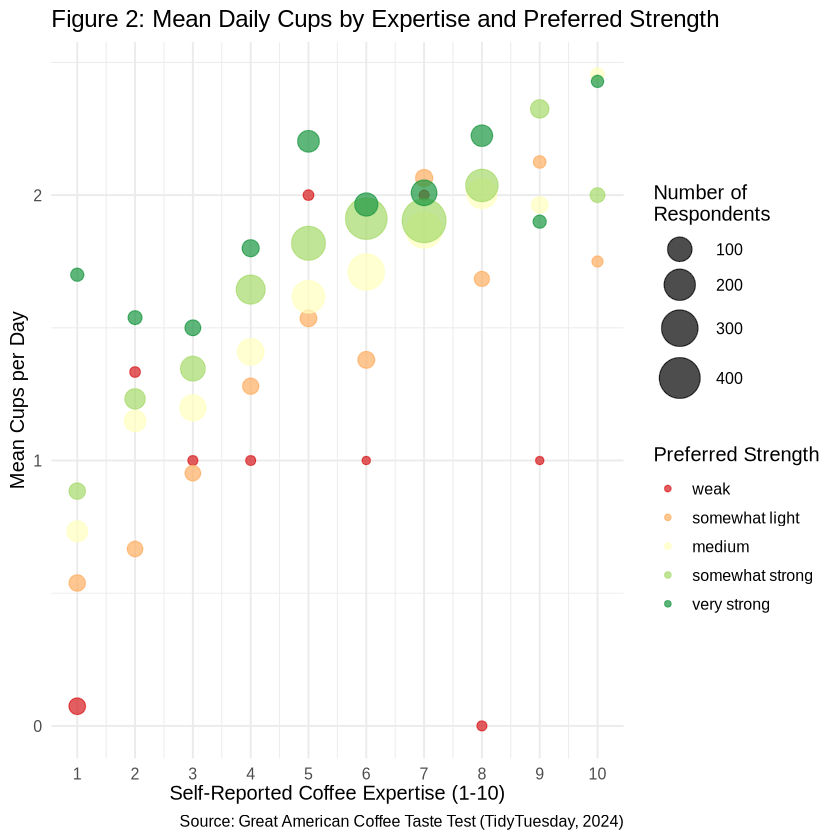

In [46]:
fig2 <- coffee_balanced_final |>
  filter(!is.na(cups_numeric), !is.na(expertise), !is.na(strength)) |>
  group_by(expertise, strength) |>
  summarise(
    mean_cups = mean(cups_numeric),
    count     = n(),
    .groups   = "drop"
  ) |>
  ggplot(aes(x = expertise, y = mean_cups, color = strength, size = count)) +
  geom_point(alpha = 0.7) +
  scale_color_brewer(palette = "RdYlGn", name = "Preferred Strength") +
  scale_size_continuous(name = "Number of\nRespondents", range = c(2, 12)) +
  scale_x_continuous(breaks = 1:10) +
  scale_y_continuous(breaks = 0:5,
                     labels = c("0", "1", "2", "3", "4", "4+")) +
  labs(
    title   = "Figure 2: Mean Daily Cups by Expertise and Preferred Strength",
    x       = "Self-Reported Coffee Expertise (1-10)",
    y       = "Mean Cups per Day",
    caption = "Source: Great American Coffee Taste Test (TidyTuesday, 2024)"
  ) +
  theme_minimal(base_size = 12)

fig2

**Figure 2** shows mean daily cups across self-reported expertise levels, with bubble color representing preferred strength and bubble size representing the number of respondents in each group. 
Three patterns emerge. First, there is a general upward trend in mean cups as expertise increases. Respondents who rate themselves `7–10` consistently show higher mean consumption than those at `1–3`, regardless of strength preference. 

Second, darker green bubbles (`very strong` and `somewhat strong`) sit consistently above lighter colored bubbles (`medium`, `somewhat light`) at the same expertise level, suggesting strength preference and expertise jointly predict higher consumption.

Third, the largest bubbles cluster around expertise `6–7` with `somewhat strong` preference, reflecting where most respondents fall, making these the most reliable estimates in the plot. The `weak` and `somewhat light` groups (red and orange) remain flat and low across all expertise levels, suggesting low-strength drinkers consume fewer cups regardless of self-reported expertise. 
Together, both plots motivate including `total_spend`, `employment_status`, `expertise`, and `strength` as predictors in the LASSO model.